# TP2 – Filtrado lineal óptimo: identificación del sistema parlante-habitación-micrófono

Modelo: `x(n)` = excitación reproducida, `y(n)` = grabación (señal deseada). Se busca el FIR `h(n)` de largo `M` que minimiza
`J = E[(y(n) - Σ h(k) x(n-k))²]`. Ecuaciones de Wiener-Hopf: `R_x h = p`, con `R_x(m) = E[x(n)x(n-m)]` (Toeplitz) y `p(m) = E[y(n)x(n-m)]`.
`J_o = σ_y² − pᵀ h_o`, y el MSE normalizado `𝓔 = J_o / σ_y²`.

In [17]:
import numpy as np, matplotlib.pyplot as plt
import pandas as pd
import soundfile as sf
from pathlib import Path
from scipy import signal
from scipy.linalg import solve_toeplitz
from scipy.interpolate import CubicSpline
from scipy.fft import rfft, irfft, next_fast_len

FS = 48_000
DIR_EXC, DIR_REC = Path('excitaciones'), Path('grabaciones')
NOMBRES = ['voz', 'musica', 'rectangular', 'barrido_lineal', 'barrido_exp', 'ruido']
plt.rcParams['figure.figsize'] = (10, 3.5)

## 1. Carga, alineación y corrección de deriva

Las grabaciones del celular (importadas con `importar.py`) empiezan en un instante arbitrario y el celular tiene su propio reloj de muestreo, distinto del de la PC (deriva de decenas de ppm → varias muestras en 10 s, lo que arruina las altas frecuencias si no se corrige). El procedimiento es:

1. **Retardo grueso** `d0` por correlación cruzada de toda la señal (para la rectangular, que es periódica y da picos repetidos cada 10 ms, se restringe la búsqueda alrededor del instante de arranque detectado por energía).
2. **Retardo por bloques** de 1 s para ver cómo evoluciona; el ajuste lineal `τ(n) = τ0 + δ·n` da la deriva relativa `δ` entre relojes.
3. **Remuestreo** de `y` (spline cúbica) para compensar `δ`, dejando `MARGEN` muestras de anticipo para que `h(n)` sea causal y se vea el arranque de la respuesta.

In [18]:
MARGEN = 100   # muestras de anticipo antes del camino directo

def xcorr_lag(y, x, rango=None):
    """Retardo d tal que y(n) ~ x(n-d) (máximo de |correlación cruzada|, por FFT). rango=(lo,hi) restringe d."""
    N = next_fast_len(len(x) + len(y))
    c = irfft(rfft(y, N) * np.conj(rfft(x, N)), N)
    c = np.concatenate([c[-(len(x) - 1):], c[:len(y)]])
    lags = np.arange(-(len(x) - 1), len(y))
    if rango is not None:
        c = np.where((lags >= rango[0]) & (lags <= rango[1]), c, 0)
    return int(lags[np.argmax(np.abs(c))])

def onset(s, frac=0.2, ms=1):
    """Primer muestra donde la envolvente (media móvil de |s|) supera frac * su máximo."""
    k = int(ms * FS / 1000)
    env = np.convolve(np.abs(s), np.ones(k) / k, mode='same')
    return int(np.argmax(env > frac * env.max()))

def retardos_bloques(x, y, d0, L=FS, W=2000, periodica=False):
    """Retardo local (x(n) aparece en y en n+τ) en bloques de L muestras, buscando en d0±W.
    Devuelve también la confianza (pico / desvío de la correlación): bloques de bajas
    frecuencias o de silencio son ambiguos y se descartan luego."""
    t, d, z = [], [], []
    for s in range(0, len(x) - L + 1, L):
        a = s + d0 - W
        if a < 0 or a + L + 2 * W > len(y): continue
        seg, xb = y[a:a + L + 2 * W], x[s:s + L]
        N = next_fast_len(len(seg) + len(xb))
        c = irfft(rfft(seg, N) * np.conj(rfft(xb, N)), N)
        c = np.concatenate([c[-(len(xb) - 1):], c[:len(seg)]])
        lags = np.arange(-(len(xb) - 1), len(seg))
        m = (lags >= W - 200) & (lags <= W + 200) if periodica else np.ones_like(lags, bool)
        k = np.argmax(np.abs(c) * m)
        d.append(a + lags[k] - s); t.append(s + L / 2); z.append(abs(c[k]) / (np.std(c) + 1e-30))
    return np.array(t), np.array(d), np.array(z)

def alinear(x, y, periodica=False, delta=None):
    """Alinea y con x. delta: deriva relativa conocida (si None, se estima de los bloques)."""
    if periodica:
        d_on = onset(y) - onset(x)
        d0 = xcorr_lag(y, x, rango=(d_on - 200, d_on + 200))   # ± ~media período de 100 Hz (240)
    else:
        d0 = xcorr_lag(y, x)
    t, d, z = retardos_bloques(x, y, d0, W=300 if periodica else 2000, periodica=periodica)
    ok = z >= 0.4 * z.max()                  # sólo bloques con correlación confiable
    p = np.polyfit(t[ok], d[ok], 1)
    for _ in range(2):                       # ajuste robusto (descarta bloques atípicos)
        r = d - np.polyval(p, t)
        ok2 = ok & (np.abs(r) <= max(3 * 1.4826 * np.median(np.abs(r[ok])), 1))
        p = np.polyfit(t[ok2], d[ok2], 1)
    delta_est, tau0 = p                      # deriva [muestras/muestra] y retardo en n=0
    if delta is not None:                    # deriva impuesta: sólo se reajusta el retardo
        tau0 = np.median(d[ok2] - delta * t[ok2]); p = np.array([delta, tau0])
    else:
        delta = delta_est

    def remuestrear(tau0):
        pos = np.arange(len(x)) * (1 + delta) + tau0 - MARGEN
        assert pos[0] >= 0 and pos[-1] <= len(y) - 1, 'la grabación no alcanza: faltan muestras al inicio/final'
        return CubicSpline(np.arange(len(y)), y)(pos)

    y_al = remuestrear(tau0)
    # Refinamiento: ya sin deriva, la correlación completa da el retardo sin sesgo (los barridos
    # tienen acople retardo/frecuencia que sesga la estimación por bloques)
    tau0 += xcorr_lag(y_al, x, rango=(MARGEN - 100, MARGEN + 100)) - MARGEN
    return remuestrear(tau0), tau0, delta * 1e6, (t, d, ok2, p)

def cargar(nombre, delta=None):
    x, fs1 = sf.read(DIR_EXC / f'{nombre}.wav'); y, fs2 = sf.read(DIR_REC / f'{nombre}.wav')
    assert fs1 == fs2 == FS, 'las grabaciones deben estar a 48 kHz (usar importar.py)'
    y_al, tau0, ppm, diag = alinear(x, y, periodica=(nombre == 'rectangular'), delta=delta)
    return x, y_al, tau0, ppm, diag

datos, diag, ppms = {}, {}, {}
def procesar(n, delta=None):
    try:
        x, y, tau0, ppm, dg = cargar(n, delta); datos[n] = (x, y); diag[n] = dg; ppms[n] = ppm
        print(f'{n:15s} retardo = {tau0:8.1f} muestras ({tau0/FS*1e3:7.1f} ms)   deriva = {ppm:+6.1f} ppm')
    except (FileNotFoundError, RuntimeError):
        print(f'{n:15s} (falta archivo)')

# 1) señales sin acople retardo/frecuencia: estiman su propia deriva
for n in ['voz', 'musica', 'rectangular', 'ruido']: procesar(n)
# 2) los barridos usan la deriva (mediana) de las anteriores: es el mismo celular y la misma PC
DELTA_REF = np.median(list(ppms.values())) * 1e-6 if ppms else None
print(f'deriva de referencia: {DELTA_REF*1e6:+.1f} ppm' if ppms else 'sin señales de referencia')
for n in ['barrido_lineal', 'barrido_exp']: procesar(n, DELTA_REF)
datos = {n: datos[n] for n in NOMBRES if n in datos}

voz             (falta archivo)
musica          (falta archivo)
rectangular     retardo =  50725.7 muestras ( 1056.8 ms)   deriva =  -46.1 ppm
ruido           retardo = 225298.0 muestras ( 4693.7 ms)   deriva =  -43.2 ppm
deriva de referencia: -44.7 ppm
barrido_lineal  retardo = 194770.5 muestras ( 4057.7 ms)   deriva =  -44.7 ppm
barrido_exp     retardo = 217784.1 muestras ( 4537.2 ms)   deriva =  -44.7 ppm


Diagnóstico: retardo por bloque y su ajuste lineal (la pendiente es la deriva relativa entre los relojes del celular y de la PC). Las cruces son bloques descartados por baja confianza (p. ej. los primeros del barrido, de muy baja frecuencia). Verificar que los círculos caen sobre la recta; si hay bloques muy dispersos, revisar esa grabación (ruido, saturación, movimientos).

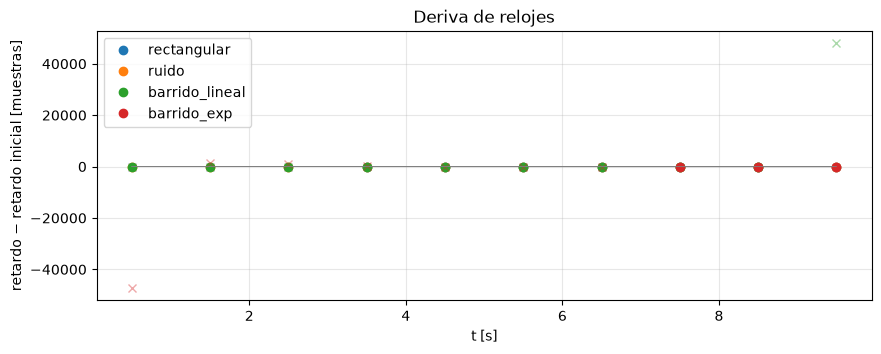

In [19]:
fig, ax = plt.subplots()
for n, (t, d, ok, p) in diag.items():
    l, = ax.plot(t[ok]/FS, d[ok] - p[1], 'o', label=n)
    ax.plot(t[~ok]/FS, d[~ok] - p[1], 'x', color=l.get_color(), alpha=.4)
    ax.plot(t/FS, np.polyval(p, t) - p[1], '-', lw=.6, color='gray')
ax.set(xlabel='t [s]', ylabel='retardo − retardo inicial [muestras]', title='Deriva de relojes'); ax.grid(alpha=.3); ax.legend()

## 2. Espectros de las excitaciones (punto 2)

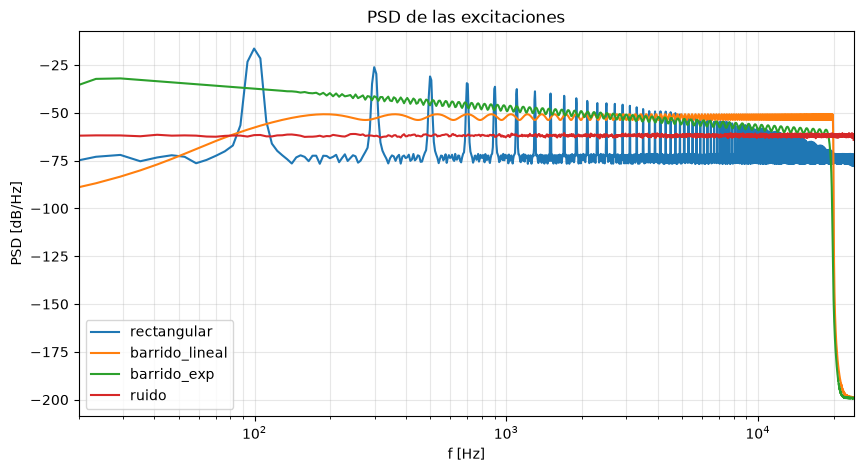

In [20]:
fig, ax = plt.subplots(figsize=(10, 5))
for n, (x, y) in datos.items():
    f, Pxx = signal.welch(x, FS, nperseg=8192)
    ax.semilogx(f[1:], 10*np.log10(Pxx[1:] + 1e-20), label=n)
ax.set(xlabel='f [Hz]', ylabel='PSD [dB/Hz]', xlim=(20, 24000), title='PSD de las excitaciones'); ax.grid(True, which='both', alpha=.3); ax.legend()

## 3. Estimador de Wiener FIR

`R_x` y `p` se estiman con correlaciones (sesgadas) calculadas una sola vez por FFT hasta `M_max`; luego `R_x h = p` se resuelve para cada `M` con Levinson (`solve_toeplitz`, O(M²)).

In [21]:
def correlaciones(x, y, Mmax):
    """rx(m) = 1/N Σ x(n)x(n-m),  p(m) = 1/N Σ y(n)x(n-m),  m = 0..Mmax-1."""
    N = len(x); L = next_fast_len(2 * N)
    X, Y = rfft(x, L), rfft(y, L)
    rx = irfft(X * np.conj(X), L)[:Mmax] / N
    p = irfft(Y * np.conj(X), L)[:Mmax] / N
    return rx, p

def wiener(x, y, M, rx=None, p=None):
    if rx is None: rx, p = correlaciones(x, y, M)
    h = solve_toeplitz(rx[:M], p[:M])
    J = np.mean(y**2) - h @ p[:M]           # J_o = σ_y² − pᵀ h_o
    return h, J, J / np.mean(y**2)          # h, J_o, 𝓔 normalizado

def mse_real(x, y, h):
    """MSE medido directamente filtrando (verificación / evaluación cruzada)."""
    e = y - signal.fftconvolve(x, h)[:len(y)]
    return np.mean(e**2) / np.mean(y**2)

## 4. Punto 3: `J_o(M)` con el barrido lineal
Reducción del cálculo: correlaciones por FFT una sola vez, Levinson en vez de inversión, y una grilla de `M` no uniforme (log). Además `J_o` es monótona decreciente en `M`, así que alcanza con una grilla gruesa y refinar cerca del codo.

[Text(0.5, 0, 'M'),
 Text(0, 0.5, 'E = J_o/σ_y²  [dB]'),
 Text(0.5, 1.0, 'MSE mínimo vs. largo del filtro (barrido lineal)')]

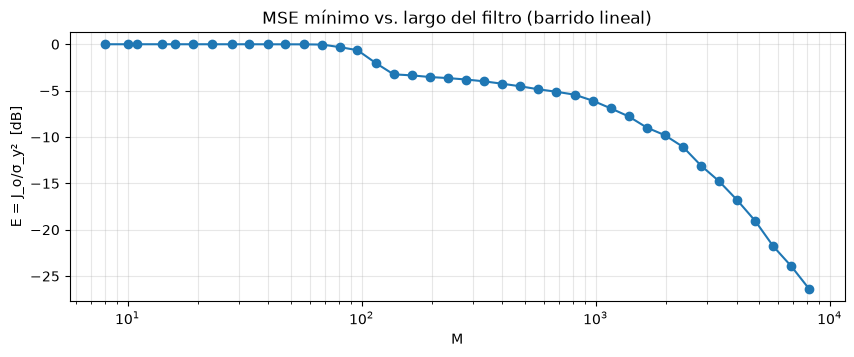

In [22]:
x, y = datos['barrido_lineal']
Mmax = 8192
rx, p = correlaciones(x, y, Mmax)
Ms = np.unique(np.round(np.geomspace(8, Mmax, 40)).astype(int))
Js = np.array([wiener(x, y, M, rx, p)[1] for M in Ms])

fig, ax = plt.subplots()
ax.semilogx(Ms, 10*np.log10(Js/np.mean(y**2)), 'o-'); ax.grid(True, which='both', alpha=.3)
ax.set(xlabel='M', ylabel='E = J_o/σ_y²  [dB]', title='MSE mínimo vs. largo del filtro (barrido lineal)')

In [23]:
# Elección de M: el menor M cuyo MSE está a menos de TOL_dB del mínimo alcanzable (a ajustar y justificar)
TOL_dB = 0.5
E_dB = 10*np.log10(Js/np.mean(y**2))
M_OPT = int(Ms[np.argmax(E_dB <= E_dB.min() + TOL_dB)])
print('M óptimo elegido:', M_OPT)

M óptimo elegido: 8192


## 5. Punto 4: `h(n)`, `Ĥ(e^{jω})` y `𝓔` para cada excitación con `M = M_OPT`

rectangular      J_o = 2.022e-04   𝓔 = 0.3830  (-4.2 dB)
barrido_lineal   J_o = 3.090e-06   𝓔 = 0.0023  (-26.4 dB)
barrido_exp      J_o = 1.502e-05   𝓔 = 0.0034  (-24.7 dB)
ruido            J_o = 1.129e-05   𝓔 = 0.1519  (-8.2 dB)


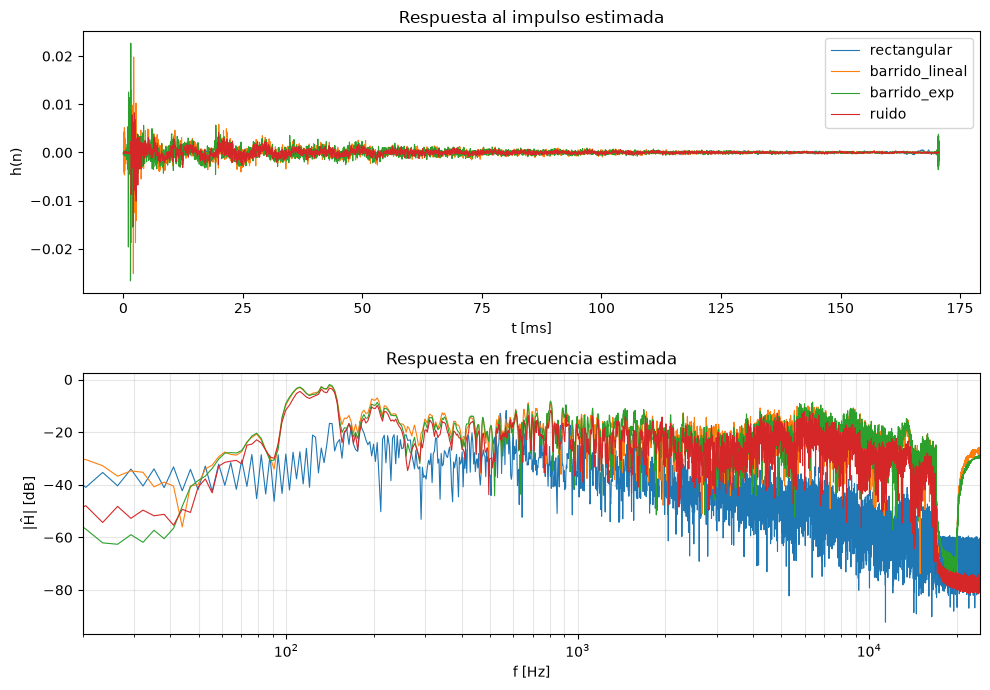

In [24]:
res = {}
for n, (x, y) in datos.items():
    h, J, E = wiener(x, y, M_OPT)
    res[n] = h
    print(f'{n:15s}  J_o = {J:.3e}   𝓔 = {E:.4f}  ({10*np.log10(E):.1f} dB)')

fig, axs = plt.subplots(2, 1, figsize=(10, 7))
for n, h in res.items():
    axs[0].plot(np.arange(len(h))/FS*1e3, h, label=n, lw=.8)
    w, H = signal.freqz(h, worN=8192, fs=FS)
    axs[1].semilogx(w[1:], 20*np.log10(np.abs(H[1:]) + 1e-12), label=n, lw=.8)
axs[0].set(xlabel='t [ms]', ylabel='h(n)', title='Respuesta al impulso estimada'); axs[0].legend()
axs[1].set(xlabel='f [Hz]', ylabel='|Ĥ| [dB]', xlim=(20, 24000), title='Respuesta en frecuencia estimada'); axs[1].grid(True, which='both', alpha=.3)
plt.tight_layout()

Evaluación cruzada: `h` estimada con la excitación *i* (filas) aplicada a las demás excitaciones *j* (columnas). Es la mejor manera de ver cuál `h` generaliza (útil para el punto 6).

In [25]:
cruz = pd.DataFrame({j: {i: 10*np.log10(mse_real(datos[j][0], datos[j][1], res[i])) for i in res} for j in datos})
cruz.round(1)   # 𝓔 en dB; filas: h de la excitación i, columnas: datos de la excitación j

,rectangular,barrido_lineal,barrido_exp,ruido
rectangular,-4.2,0.1,0.1,0.2
barrido_lineal,17.4,-26.4,-0.8,1.5
barrido_exp,17.7,2.9,-24.7,4.4
ruido,15.5,-1.9,-2.2,-8.3


## 6. Punto 6: filtrar la música con la `h` elegida y comparar auditivamente

In [26]:
H_ELEGIDA = 'barrido_lineal'   # <- completar según el análisis y justificar
import sounddevice as sd
if 'musica' in datos:
    xm, ym = datos['musica']
    y_est = signal.fftconvolve(xm, res[H_ELEGIDA])[:len(ym)]
    sf.write('musica_filtrada.wav', (y_est/np.max(np.abs(y_est))*.8).astype(np.float32), FS)
    sf.write('musica_grabada_alineada.wav', (ym/np.max(np.abs(ym))*.8).astype(np.float32), FS)
    # sd.play(y_est/np.max(np.abs(y_est))*.8, FS); sd.wait()     # escuchar filtrada
    # sd.play(ym/np.max(np.abs(ym))*.8, FS); sd.wait()           # escuchar grabada